In [5]:
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt

from collections import defaultdict
from google.colab import userdata

try:
    from roboflow import Roboflow
except ImportError:
    print("Installing Roboflow library...")
    !pip install roboflow
    from roboflow import Roboflow

try:
  from ultralytics import YOLO
except ImportError:
  print("Installing Ultralytics library...")
  !pip install ultralytics
  from ultralytics import YOLO



### Cómo configurar la Roboflow API Key en Colab

1. Haz clic en el icono de la llave (**🔑 Secrets**) en el menú de la izquierda.
2. Agrega un nuevo secreto con el nombre: `RoboflowAPIKey`.
3. Pega tu API Key de Roboflow en el campo de valor.
4. Asegúrate de activar el interruptor de **Notebook access** para que este cuaderno pueda leer la clave.

El código que usamos intentará leer esta clave automáticamente con `userdata.get('RoboflowAPIKey')`.

In [ ]:
import os
from roboflow import Roboflow
from google.colab import userdata

# Intentar obtener la clave de los Secrets de Colab
try:
    api_key = userdata.get('RoboflowAPIKey')
    rf = Roboflow(api_key=api_key)

    project = rf.workspace("raiyan8018").project("sunflower-mn2cr")
    version = project.version(1)
    dataset = version.download("yolov8")

    print(f"Dataset cargado exitosamente en: {dataset.location}")
except userdata.NotebookAccessError:
    print("ERROR: No tienes acceso al secreto 'RoboflowAPIKey'. Asegúrate de activar el interruptor de 'Notebook access' en el menú de Secrets (🔑).")
except Exception as e:
    print(f"Ocurrió un error: {e}")

## Análisis exploratorio de datos (EDA)


In [20]:

# Assuming YOLOv8 format, check for train/valid/test image and label directories
train_images = glob.glob(os.path.join(dataset.location, 'train', 'images', '*.jpg'))
val_images = glob.glob(os.path.join(dataset.location, 'valid', 'images', '*.jpg'))
test_images = glob.glob(os.path.join(dataset.location, 'test', 'images', '*.jpg'))

print(f"Cantidad de images en train: {len(train_images)}")
print(f"Cantidad de images en validación: {len(val_images)}")
print(f"Cantidad de images en test {len(test_images)}")

# Let's also try to read the data.yaml file if it exists, for class information
data_yaml_path = os.path.join(dataset.location, 'data.yaml')
classes = []
if os.path.exists(data_yaml_path):
    import yaml
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
    if 'names' in data_config:
        classes = data_config['names']
        print(f"Clases en data.yaml: {classes}")
    else:
        print("No 'names' key found in data.yaml.")
else:
    print(f"data.yaml not found at {data_yaml_path}.")

Cantidad de images en train: 3429
Cantidad de images en validación: 428
Cantidad de images en test 429
Clases en data.yaml: ['Backside-Sunflower', 'Sunflower']


Displaying random image: /content/Sunflower-1/train/images/MVI_9840-MP4_frame5_jpg.rf.024c445cd8c01d86e3e2b7f12502d9a6.jpg


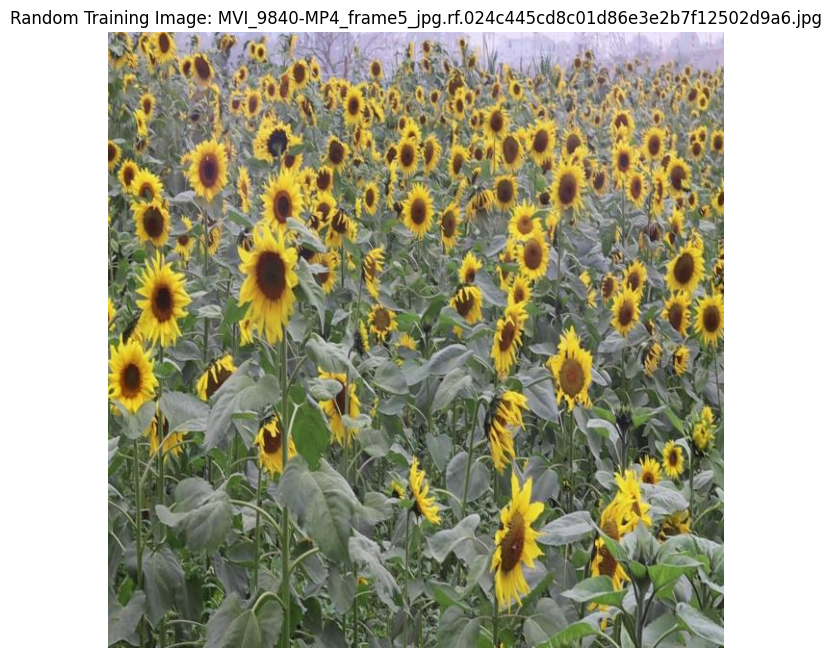

In [21]:
# Select a random image from the training set
if train_images:
    random_image_path = random.choice(train_images)
    print(f"Displaying random image: {random_image_path}")

    # Read the image using OpenCV
    # OpenCV reads images in BGR format, so convert to RGB for matplotlib
    image = cv2.imread(random_image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.title(f"Random Training Image: {os.path.basename(random_image_path)}")
    plt.axis('off') # Hide axes for cleaner display
    plt.show()
else:
    print("No training images found to display.")

In [7]:
# Load a pre-trained YOLOv8n model (nano version, good for quick tests)
model = YOLO('yolov8n.pt')  # You can choose other models like 'yolov8s.pt', 'yolov8m.pt', etc.

YOLOv8 model loaded successfully.


## Entrenar el modelo YOLOv8 con el conjunto de datos personalizado

Ahora entrenaremos el modelo YOLOv8 utilizando el método `model.train()`. Los parámetros clave incluyen:

*   `data`: Ruta a nuestro archivo `data.yaml`, que define la estructura del conjunto de datos y los nombres de las clases.
*   `epochs`: El número de épocas de entrenamiento. Para una demostración rápida, comenzaremos con un número pequeño. Puedes aumentar esto para obtener un mejor rendimiento.
*   `imgsz`: El tamaño de la imagen de entrada. Generalmente es bueno comenzar con un tamaño estándar como 640.
*   `batch`: El tamaño del lote (batch size) para el entrenamiento. Ajústalo según la memoria de tu GPU.
*   `name`: Un nombre para la ejecución del entrenamiento, lo que ayuda a organizar los resultados en el directorio `runs/detect`.

In [10]:
# Train the model with your custom dataset
# Adjust epochs, imgsz, and batch as needed for your specific task and hardware
trained_model = model.train(
    data=os.path.join(dataset.location, 'data.yaml'),
    epochs=10,  # Start with a small number of epochs
    imgsz=640,  # Standard input image size for YOLOv8
    batch=16,   # Adjust based on GPU memory. Lower if you encounter OOM errors.
    name='yolov8n_sunflower_detection_v1' # Name for this training run
)

print("Model training complete.")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Sunflower-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_sunflower_detection_v1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

## Validación del Modelo Entrenado

Después del entrenamiento, es crucial validar el modelo utilizando los mejores pesos (`best.pt`) generados para ver métricas precisas de precisión y exhaustividad (Recall).

In [22]:
# Localizar los mejores pesos de la última ejecución
# El entrenamiento guardó los resultados en 'runs/detect/yolov8n_sunflower_detection_v1-2'
best_model_path = '/content/runs/detect/yolov8n_sunflower_detection_v1-2/weights/best.pt'

if os.path.exists(best_model_path):
    # Cargar el modelo entrenado
    model_trained = YOLO(best_model_path)

    # Ejecutar validación
    metrics = model_trained.val()

    print("Validación completada.")
    print(f"mAP50-95: {metrics.box.map:.3f}")
    print(f"mAP50: {metrics.box.map50:.3f}")
else:
    print("No se encontró el archivo best.pt. Verifica la ruta de entrenamiento.")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2407.5±446.0 MB/s, size: 90.0 KB)
val: Scanning /content/Sunflower-1/valid/labels.cache... 428 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 428/428 163.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.3it/s 21.2s
                   all        428      31257      0.846      0.788      0.874       0.52
             Sunflower        428      31257      0.846      0.788      0.874       0.52
Speed: 2.7ms preprocess, 4.4ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to /content/runs/detect/val-3
Validación completada.
mAP50-95: 0.520
mAP50: 0.874
